**整体 Pipeline 概览**

从一个 base model 到具备工具调用、多步推理能力的 agent，需要依次经历以下几个阶段（DPO 和 RLHF 的阶段不是必需的）

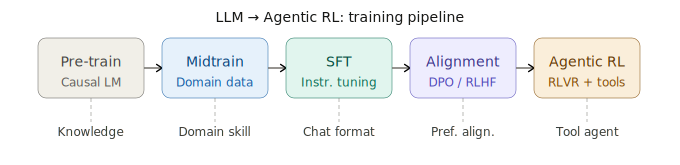

In [4]:
from IPython.display import SVG, display
display(SVG(filename='./llm_to_agentic_training_pipeline.svg'))

**Base Pre-training：大规模自监督预训练**

Base model 的产生是在万亿级别 token 的语料上进行自监督的 **next-token prediction**，损失函数为：

$$
L_\texttt{NTP} = -Σ_t  log p_\theta (x_t | x_{<t})
$$

此阶段完全是无监督的——模型仅从序列本身的统计结构中学习世界知识、语言规律和基本的推理模式。训练数据通常混合 Common Crawl、书籍、代码、学术论文等，并经过仔细的去重与质量过滤。这一阶段产生的 base model 具有强大的续写能力，但没有对齐、没有指令跟随能力，也没有特定领域的深度知识。

**CPT 或 Midtraining：继续预训练与知识注入**

**Continued Pre-Training（CPT）** 或 **Midtraining**（Llama-3 技术报告中的用语）指的是：在得到 base model 之后，继续用 causal LM 损失训练，但数据分布从通用网络语料切换为精心配比的特定领域数据。

训练目标与 pre-training 完全相同，没有任何格式上的改变：

$$
L_\texttt{CPT} = -Σ_t log p_\theta(x_t | x_{<t})   （在领域语料上）
$$

CPT 的典型用途包括：

- **领域知识注入**：用高质量数学题解（如 NuminaMath）、代码仓库（GitHub）、科学文献大量补充某一领域能力。典型例子是 CodeLlama（在 Llama 2 上做 500B token 代码 CPT），DeepSeek-Coder，Qwen-Math。
- **知识截止日期更新**：用近期语料补充基座模型缺失的时事知识。
- **上下文长度扩展**：这是 CPT 阶段最关键的工程任务之一，需要单独讨论。本文会在下一页进行大致展开，后续会单独写一篇文章讲清楚。

CPT 阶段通常比 pre-training 短得多（一般是数十亿到数千亿 token），学习率也更小，防止灾难性遗忘已有的知识。

**Context Length Extension：上下文长度扩展**

现代 LLM 普遍采用 **Rotary Position Embedding（RoPE）**。其核心思想是：将位置信息编码为旋转操作，使得两个位置 $m$、$n$ 之间的注意力分数只依赖于相对位置差 $m - n$。

对于维度为 $d$ 的注意力头，RoPE 将其分为 $d/2$ 个 2D 旋转子空间。在第 $i$ 个子空间中，位置 $m$ 处的旋转角度为：

$$
旋转角(m, i) = m × θ_i，   θ_i = base^{-2i/d}，   base = 10000（默认）
$$

$θ_i$ 随 $i$ 增大而指数递减：$i=0$ 的维度是**高频**（旋转角增长快，模式周期短），$i=d/2-1$ 的维度是**低频**（旋转角增长极慢，模式周期长）。

长上下文的核心问题是，假设 base model 的训练上下文为 $L_\theta = 2048$，现在希望在推理时使用 $L = 8192$。

**高频维**：$\theta_0 = 1.0$，在每 $2π$ 个位置完整旋转一周，所以 `angle(m, 0) mod 2π` 是周期性的，模型在任何位置都见过这种角度值，因此是**安全**的。

**低频维**：$θ_{d/2-1} ≈ 10000^{-0.984} ≈ 1.04×10⁻⁴$，在训练期间（位置 $0$ 到 $2047$）见到的最大角度约为 $2047 × 1.04×10⁻⁴ ≈ 0.21 rad$。当推理时位置达到 $8191$，角度变为 $8191 × 1.04×10⁻⁴ ≈ 0.85 rad$，而这是模型之前从未见过的角度值，进入了**分布外（OOD）区域**，导致注意力计算失准。

**低频维是长上下文的瓶颈，高频维是安全的。**

**解决方案：插值**
- **Positional Interpolation（PI，线性缩放）**：将所有位置按比例压缩，$m → m × (L₀/L)$，使得扩展后的最大角度回到训练分布范围内，本质上就是插值；当然，代价是相邻位置的差距变小，模型需要区分更细粒度的位置差，通常需要几百到数千步微调来恢复性能；
- **YaRN（NTK-aware Interpolation）**：注意到不同频率的维度对 OOD 的敏感程度不同；YaRN 对高频维不做缩放，因为它们已经在周期以内了；对低频维做 PI 缩放，对中间频率维做渐变混合；这使得插值更精确，所需的微调 step 更少；
- **LongRoPE**：进一步对每个维度学习非均匀的缩放因子，并结合上下文长度渐进扩展课程；
- **训练课程设计**：长度扩展通常采用先短后长的课程，如先在 $L_\theta$ 上 CPT，再逐步增加至 $4L_\theta$，并在数据中混入长篇文档，如书籍章节、长代码文件、合成长上下文数据等等。

**SFT：监督微调与指令对齐**

SFT 是第一个引入**格式**的阶段。训练数据由 `(system, user instruction, assistant response)` 三元组构成，损失函数**只在 assistant 的 token 上计算**（instruction 和 system tokens 被 mask 掉）：

$$
L_\texttt{SFT} = -Σ_{t ∈ \text{response}} log p_θ(x_t | x_{<t})
$$

这使模型学会「被提问时如何作答」而非「如何把一段文本续写下去」。

需要注意的是，对于 **agentic SFT**，训练数据还包括工具调用格式（`<tool_call>...</tool_call>`）、多轮对话轨迹、带有推理步骤的 chain-of-thought 示例（来自人类标注或者干脆强模型蒸馏），从而引导模型工具调用的基本语法。高质量 SFT 数据通常通过 rejection sampling，即用强模型对弱模型的采样做过滤，或人工精标得到；数据量往往只需要数十万到数百万条。

**Alignment：RLHF、DPO 与 GRPO**

RLHF 的经典路线，训练一个奖励模型 $r_φ(x, y)$ 对 response 打分，然后用 PPO 算法优化：

$$
\max_θ  \text{E}_{x, y} [r_φ(x,y)]  −  β · \text{KL}(π_θ || π_\text{ref})
$$

其中 KL 散度项防止模型偏离 SFT 初始化太远，出现 reward hacking。PPO 需要维护 actor、critic、reward model 三个模型，工程复杂度高（GRPO 的诞生动机）。

**DPO（直接偏好优化）**

DPO 发现上述 RLHF 目标有**封闭形式**的最优解，说白了就是不需要基于外源性的奖励函数作为绝对指标，基于 Bradley Terry 模型构建偏好奖励；可以直接将偏好数据 $(x, y_w, y_l)$，其中 $y_w$ 为 chosen、$y_l$ 为 rejected，并转化为分类损失：

$$
L_\texttt{DPO} = -\text{E}_{x, y_w, y_l} [\log σ( β·\frac{log π_θ(y_w|x)}{π_\text{ref}(y_w|x)} 
                  − β·\frac{\log π_θ(y_l|x)}{π_\text{ref}(y_l|x)} ) ]
$$

括号内的差值即为**隐式奖励差**（implicit reward margin），该 loss 鼓励模型对 chosen response 的概率相对 reference model 上升、对 rejected response 下降。这里介绍的也比较笼统，但是对于整体串联好理解，之后也会写一篇关于 DPO 的小文。

**Agentic RL（RLVR）：可验证奖励强化学习**

**RLVR（RL with Verifiable Rewards）** 是当前训练 reasoning agent 模型的核心范式。其关键性质是，奖励信号来自**可程序化验证**的外部检验，而不是主观的人类偏好打分，例如
- **数学**：答案是否等于标准答案，基于数值比对；
- **代码**：生成代码是否通过全部测试用例；
- **工具调用**：工具返回结果是否满足任务约束，以及任务是否解决；
- 其他任何自定义任务，只要有外源沙箱和自定的奖励函数；

采样的轨迹结构为多步序列：`思考（CoT）→ 工具调用 → 工具结果观测 → 继续思考（重复多次） → 最终答案`。结果观测也会被 mask 掉。奖励通常是**结果奖励（outcome reward）**，只在轨迹结束时发放；也可以结合**过程奖励模型**在中间步骤给出稠密信号。RLVR 的关键优势在于，奖励信号几乎无噪声、是无偏的，且实证可以无限扩展。DeepSeek-R1、OpenAI o1/o3 系列均属于此类。

如下是一个基于 torch api 的简易 LM 实现。

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(123)
VOCAB, D, HEADS, LAYERS, SEQ = 256, 64, 4, 2, 32

class TinyLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, D)
        enc = nn.TransformerEncoderLayer(D, HEADS, dim_feedforward=128, batch_first=True, dropout=0.1)
        self.tfm = nn.TransformerEncoder(enc, LAYERS)
        self.head = nn.Linear(D, VOCAB, bias=False)

    def forward(self, ids): # ids: (B, T)
        T = ids.size(1)
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=ids.device)
        h = self.tfm(self.emb(ids), mask=mask, is_causal=True)
        return self.head(h) # logits: (B, T, V)

model = TinyLM()
model

TinyLM(
  (emb): Embedding(256, 64)
  (tfm): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Linear(in_features=64, out_features=256, bias=False)
)

如下实现简易的 NTP 目标构建，CE 损失计算和回传，以及梯度剪裁。可以看到最开始的 LM 和在词表上的均匀分布相近，这种比较思想来自于 Andrej 的 youtube 课程。

In [10]:
def pretrain_step(model, optimizer, ids):
    inp, tgt = ids[:, :-1], ids[:, 1:] # one step teacher forcing
    logits = model(inp) # (B, T - 1, V)

    B, T, V = logits.shape
    loss = F.cross_entropy(
        logits.reshape(B * T, V),
        tgt.reshape(B * T),
        ignore_index=-100 # any token with target -100 will be ignored in loss for SFT
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # clip grad to avoid explosion
    optimizer.step()
    return loss.item()

opt = torch.optim.AdamW(model.parameters(), lr=1e-3) # lr = 1e-3 is large for real training (since model is small)
ids = torch.randint(0, VOCAB, (4, SEQ)) # (4, 32)
loss_val = pretrain_step(model, opt, ids)
print(f"[Pretrain] NTP loss = {loss_val:.4f}")   
print(f"ln({VOCAB})={torch.log(torch.tensor(VOCAB)).item():.2f} at random init")

[Pretrain] NTP loss = 5.7945
ln(256)=5.55 at random init


如下对 rollout 过程做一个简要抽象，该过程不需要计算梯度。

In [33]:
@torch.no_grad()
def rollout(model, prompt_ids, G=8, max_new=16, temperature=1.0):
    model.eval()
    P = prompt_ids.size(1)
    ctx = prompt_ids.expand(G, -1).clone() # copy prompt to get (G, P)

    all_toks, all_lps = [], []

    for _ in range(max_new):
        logits = model(ctx)[:, -1, :] # last token
        logits = logits / temperature
        probs  = F.softmax(logits, dim=-1)
        next_tok = torch.multinomial(probs, 1) # (G, 1) ids sampled from distribution
        lp = torch.log(probs.gather(1, next_tok) + 1e-9)  # (G, 1) log probabilities

        all_toks.append(next_tok)
        all_lps.append(lp)
        ctx = torch.cat([ctx, next_tok], dim=1)

    completions = torch.cat(all_toks, dim=1)
    log_probs = torch.cat(all_lps, dim=1)
    print(f"[Rollout] {G} completions × {max_new} tokens")
    print(f"mean log-prob per token: {log_probs.mean().item():.4f}")
    print(f"first completion tokens: {completions[0].tolist()}")
    return completions, log_probs # (G, max_new), (G, max_new)

prompt = torch.randint(0, VOCAB, (1, 8))
completions, lp_old = rollout(model, prompt, G=8, max_new=16)

[Rollout] 8 completions × 16 tokens
mean log-prob per token: -5.4248
first completion tokens: [207, 255, 109, 123, 59, 88, 100, 114, 1, 166, 220, 58, 145, 60, 182, 5]


最后是 GRPO 基于 rollouts 与外部奖励计算目标和反向传播的 demo code。这里奖励设计是如果 rollout 中出现了 42 号 token 就有分。

In [55]:
a = torch.randn(2, 3, 4)
ids = torch.randint(0, 3, (2, 3))


tensor([[0, 0, 2],
        [1, 0, 0]])

In [64]:
def external_reward(completions, target_token=42): 
    # simulates an external reward function that gives higher reward if target_token appears more in the completion
    return (completions == target_token).float().mean(dim=1) # (G, )

def grpo_step(model, ref_model, optimizer, prompt_ids, completions, beta=0.5):
    model.train()
    G, T = completions.shape
    P = prompt_ids.size(1)

    rewards = external_reward(completions)             # (G,)
    mu, sigma = rewards.mean(), rewards.std() + 1e-8
    advantages = (rewards - mu) / sigma                # (G,)
    print(f"\n[GRPO] rewards = {rewards.tolist()}")
    print(f"μ={mu:.3f}, σ={sigma:.3f}")
    print(f"advantages = {[f'{a:.3f}' for a in advantages.tolist()]}")

    full_ids  = torch.cat([prompt_ids.expand(G, -1), completions], dim=1) # (G, P + T)
    logits_new = model(full_ids) # (G, P + T, V)
    logits_comp = logits_new[:, (P - 1):(-1), :] # (G, T, V)
    lp_new = F.log_softmax(logits_comp, dim=-1) # (G, T, V)
    lp_new = lp_new.gather(2, completions.unsqueeze(2)).squeeze(2)  # (G, T)

    with torch.no_grad():
        logits_ref  = ref_model(full_ids)
        logits_ref_c = logits_ref[:, (P - 1):(-1), :]
        lp_ref = F.log_softmax(logits_ref_c, dim=-1)
        lp_ref = lp_ref.gather(2, completions.unsqueeze(2)).squeeze(2)

    seq_lp_new = lp_new.sum(dim=1) 
    seq_lp_ref = lp_ref.sum(dim=1) 

    pg_loss = -(advantages * seq_lp_new).mean()
    kl_div = (lp_new - lp_ref).mean()
    kl_div = kl_div.clamp(min=0) # KL ≥ 0 for stability

    loss = pg_loss + beta * kl_div

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    print(f"pg_loss={pg_loss.item():.4f}  kl={kl_div.item():.4f}  total={loss.item():.4f}")
    return loss.item()

ref_model = TinyLM()
ref_model.load_state_dict(model.state_dict())
for p in ref_model.parameters():
    p.requires_grad_(False)

opt2 = torch.optim.AdamW(model.parameters(), lr=1e-4)
grpo_step(model, ref_model, opt2, prompt, completions, beta=0.5)


[GRPO] rewards = [0.0, 0.0, 0.0, 0.0, 0.0625, 0.0, 0.0, 0.0]
μ=0.008, σ=0.022
advantages = ['-0.354', '-0.354', '-0.354', '-0.354', '2.475', '-0.354', '-0.354', '-0.354']
pg_loss=-2.6202  kl=0.0000  total=-2.6202


-2.620162010192871